# Uplift modeling for Better ROI

### Data Simulation

In [283]:
! pip install duecredit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 45.7 MB/s eta 0:00:00


In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from causalml.dataset import synthetic_data
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

y, X, T, _, _, e = synthetic_data(mode=1, n=5000, p=9, sigma=1)
df = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(X.shape[1])])
df["Y"] = y
df["T"] = T
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,Y,T
0,0.778808,0.926976,0.458925,0.744573,0.725222,0.172976,0.429163,0.286159,0.899471,0.571727,0
1,0.898841,0.658814,0.737702,0.395029,0.403239,0.391257,0.628719,0.767817,0.801718,0.108824,0
2,0.649337,0.466707,0.205267,0.583693,0.152855,0.866439,0.778617,0.464340,0.175086,0.552470,0
3,0.623073,0.939821,0.713122,0.799136,0.369910,0.483498,0.417778,0.124163,0.815775,0.879232,1
4,0.996931,0.011547,0.502730,0.927863,0.524084,0.162152,0.384963,0.764537,0.508520,1.340197,0


In [155]:
feature_cols = ['x1','x2','x3','x4','x5','x6','x7','x8','x9']
outcome_col = 'Y'
treat_col = 'T'
df.groupby(treat_col)['Y'].agg(['count','mean'])

,count,mean
T,,
0,2374,1.056579
1,2626,1.906892


In [156]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df,test_size=0.3,random_state=42, stratify=df["T"])
df_train.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,Y,T
408,0.769320,0.963996,0.060597,0.358880,0.073746,0.680719,0.632843,0.894025,0.889245,2.150909,0
1669,0.819276,0.640177,0.756873,0.283348,0.267947,0.013001,0.812799,0.151918,0.356847,1.072658,1
4627,0.764346,0.742436,0.034122,0.959445,0.688291,0.887943,0.310558,0.117754,0.725767,2.629216,1
3281,0.216922,0.194035,0.923488,0.027500,0.058319,0.978198,0.094788,0.411000,0.491208,1.406899,0
2148,0.426958,0.076819,0.904401,0.228951,0.309736,0.505542,0.883141,0.172859,0.774204,0.302954,0


## Modeling Method 1: with CausalML Directly

In [157]:
from causalml.inference.meta import BaseTRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Initialize Learner with any base learner
# learner = BaseTRegressor(learner=GradientBoostingRegressor())
learner = BaseTRegressor(learner=LinearRegression())

# Fit the model
learner.fit(X=df_train[feature_cols], treatment=df_train[treat_col], y=df_train[outcome_col])
# Predict uplift
uplift_hat_m1 = learner.predict(df_test[feature_cols])

In [158]:
def deciles(
    df_scored: pd.DataFrame,
    uplift_hat,
    decile_col: str = "decile",
    treat_col: str = "T",
    outcome_col: str = "Y", # Y is continuous (e.g., revenue or count)
    uplift_pred_col: str = "uplift_hat"
):
    df = df_scored.copy()
    q = 10
    df[uplift_pred_col] = uplift_hat

    # Rank and assign deciles (1 = highest predicted uplift)
    rank = df[uplift_pred_col].rank(method="first", ascending=False)
    df[decile_col] = (pd.qcut(rank, q=q, labels=False) + 1).astype(int)

    grouped = df.groupby(decile_col, sort=True)

    # Base counts
    base = grouped.agg(
        n=(outcome_col, "size"),
        n_treated=(treat_col, lambda s: int((s == 1).sum()))
    ).sort_index()
    base["n_untreated"] = base["n"] - base["n_treated"]

    # Treated/untreated mean outcome per decile (explicit means)
    means = (
        df.groupby([decile_col, treat_col])[outcome_col]
          .mean()
          .unstack(fill_value=np.nan)
          .rename(columns={0: "untreated_Y", 1: "treated_Y"})
          .sort_index().round(2)
    )

    # Join and compute actual uplift (= mean difference)
    summary = (
        base.join(means, how="left")
            .join(grouped[uplift_pred_col].mean().rename("uplift_pred"), how="left")
            .reset_index()
            .sort_values(decile_col).round(2)
    )
    summary["uplift"] = summary["treated_Y"] - summary["untreated_Y"]

    # Incremental outcome units per decile
    summary["incre_sum"] = summary["uplift"] * summary["n_treated"]

    # Cumulative metrics for the uplift curve
    summary["cum_incre_ttl"] = summary["incre_sum"].cumsum()
    summary["cum_n"] = summary["n"].cumsum()
    total_n = summary["n"].sum()
    summary["cum_coverage"] = summary["cum_n"] / total_n  # in [0,1]
    total_incremental_units = summary["incre_sum"].sum()

    return summary, df
    
summary_m1, test_scored_m1 = deciles(
    df_scored=df_test,
    uplift_hat=uplift_hat_m1)

summary_m1

,decile,n,n_treated,n_untreated,untreated_Y,treated_Y,uplift_pred,uplift,incre_sum,cum_incre_ttl,cum_n,cum_coverage
0,1,150,111,39,1.03,2.18,1.14,1.15,127.65,127.65,150,0.1
1,2,150,127,23,1.32,2.16,0.97,0.84,106.68,234.33,300,0.2
2,3,150,126,24,1.57,2.17,0.86,0.60,75.60,309.93,450,0.3
3,4,150,113,37,1.28,1.93,0.77,0.65,73.45,383.38,600,0.4
4,5,150,93,57,1.36,1.83,0.69,0.47,43.71,427.09,750,0.5
5,6,150,74,76,0.93,1.52,0.61,0.59,43.66,470.75,900,0.6
6,7,150,58,92,1.03,1.57,0.53,0.54,31.32,502.07,1050,0.7
7,8,150,45,105,1.06,1.42,0.43,0.36,16.20,518.27,1200,0.8
8,9,150,24,126,0.89,0.93,0.31,0.04,0.96,519.23,1350,0.9
9,10,150,17,133,0.92,0.72,0.12,-0.20,-3.40,515.83,1500,1.0


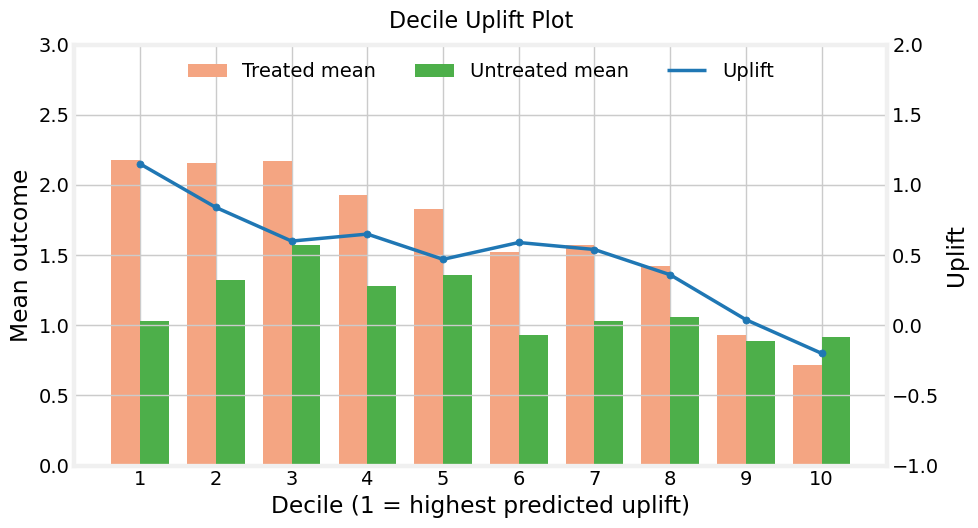

In [159]:
def plot_deciles(
    df: pd.DataFrame,
    decile_col: str = "decile",
    treated_col: str = "treated_Y",
    untreated_col: str = "untreated_Y",
    title: str = "Decile Uplift Plot"
):

    # Sort by decile to ensure left-to-right
    d = df.sort_values(decile_col).reset_index(drop=True)
    d[decile_col] = d[decile_col].astype(int)
    bin_labels = d[decile_col]

    treated = d[treated_col].astype(float).to_numpy()
    untreated = d[untreated_col].astype(float).to_numpy()
    uplift = treated - untreated

    # Positions for side-by-side bars
    n = len(bin_labels)
    x = np.arange(n)
    bar_width = 0.38

    # Colors
    color_treated = "#f4a582"   # peach
    color_untreated = "#4daf4a" # green
    color_line = "#1f77b4"      # blue

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="white")
    ax.set_facecolor("white")

    # Bars: treated vs. untreated mean outcome
    ax.bar(x - bar_width/2, treated, width=bar_width, label="Treated mean", color=color_treated)
    ax.bar(x + bar_width/2, untreated, width=bar_width, label="Untreated mean", color=color_untreated)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_xlabel("Decile (1 = highest predicted uplift)")
    ax.set_ylabel("Mean outcome")
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0,3)
    
    # Uplift line on right y-axis (treated - untreated)
    ax2 = ax.twinx()
    ax2.plot(x, uplift, color=color_line, linewidth=2.5, label="Uplift")
    ax2.scatter(x, uplift, color=color_line, s=26)
    ax2.set_ylabel("Uplift")
    ax2.set_ylim(-1,2)

    # Legend combining both axes
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc="upper center", ncol=3, frameon=False)

    plt.tight_layout()
    plt.show()

plot_deciles(
    df=summary_m1,
    decile_col="decile",
    treated_col="treated_Y",
    untreated_col="untreated_Y",
    title="Decile Uplift Plot"
)

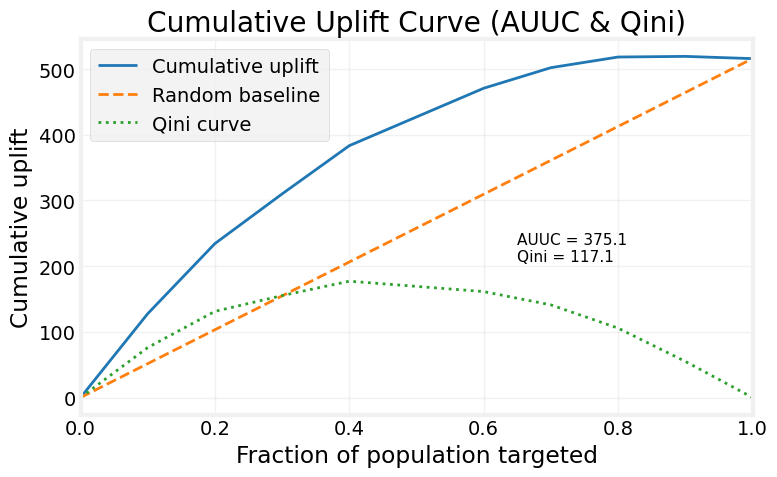

375.06149999999997 117.14649999999999


In [160]:
def auuc_qini(
    decile_df: pd.DataFrame,
    coverage_col: str = "cum_coverage",
    cum_uplift_col: str = "cum_incre_ttl",
    title: str = "Cumulative Uplift Curve (AUUC & Qini)"
):

    # Ensure sorted by coverage (left to right)
    d = decile_df.sort_values(coverage_col).reset_index(drop=True)

    # X and Y for the curve
    x = d[coverage_col].to_numpy()
    y = d[cum_uplift_col].to_numpy()

    # Guard: ensure first point starts at 0 coverage & 0 uplift (optional, but typical)
    # If not, prepend a zero point to anchor the curve.
    if len(x) == 0 or x[0] > 0.0 or y[0] != 0.0:
        x = np.insert(x, 0, 0.0)
        y = np.insert(y, 0, 0.0)

    # Total cumulative uplift at full coverage
    total_cum_uplift = float(y[-1])

    # Baseline: random targeting accumulates linearly with coverage
    baseline = x * total_cum_uplift

    # AUUC: area under the cumulative uplift curve
    auuc = float(np.trapz(y, x))

    # Qini: area between model curve and random baseline
    qini = float(np.trapz(y - baseline, x))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.plot(x, y, label="Cumulative uplift", color="#1f77b4", linewidth=2)
    ax.plot(x, baseline, label="Random baseline", color="#ff7f0e", linestyle="--", linewidth=2)
    ax.plot(x, y - baseline, label="Qini curve", color="#2ca02c", linestyle=":", linewidth=2)

    ax.set_xlabel("Fraction of population targeted")
    ax.set_ylabel("Cumulative uplift")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    # y-limit auto; you can set ax.set_ylim(bottom=0) if uplift is always non-negative
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    # Annotate AUUC/Qini in-plot
    ymin, ymax = float(np.nanmin(y)), float(np.nanmax(y))
    y_annot = ymin + 0.4 * (ymax - ymin) if ymax > ymin else 0.0
    ax.annotate(f"AUUC = {auuc:.1f}\nQini = {qini:.1f}",
                xy=(0.65, y_annot), fontsize=11)

    plt.tight_layout()
    plt.show()

    curve_df = pd.DataFrame({"coverage": x, "cum_uplift": y, "baseline": baseline})
    return {"AUUC": auuc, "Qini": qini, "curve_df": curve_df}

metrics = auuc_qini(
    decile_df=summary_m1,
    coverage_col="cum_coverage",
    cum_uplift_col="cum_incre_ttl",
    title="Cumulative Uplift Curve (AUUC & Qini)"
)

print(metrics["AUUC"], metrics["Qini"])


## Modeling Method 2: Treated and Controlled Separately

In [161]:
from sklearn.linear_model import LinearRegression
# Define the learners
model_treated = LinearRegression()
model_control = LinearRegression()

# Fit treated model on T == 1
treated_group = df_train["T"] == 1
model_treated.fit(df_train.loc[treated_group, feature_cols],
                  df_train.loc[treated_group, "Y"])

# Fit control model on T == 0
control_group = df_train["T"] == 0
model_control.fit(df_train.loc[control_group, feature_cols],
                  df_train.loc[control_group, "Y"])

# Predict potential outcomes for test set
mu1_hat = model_treated.predict(df_test[feature_cols])  # E[Y|T=1, X]
mu0_hat = model_control.predict(df_test[feature_cols])  # E[Y|T=0, X]

# Compute uplift
uplift_hat_m2 = mu1_hat - mu0_hat

# Check first few predictions
print("Predicted uplift:", uplift_hat_m2[:10])

Predicted uplift: [0.32967792 0.94834218 0.07063865 0.63208015 0.31715171 0.80335595
 0.9613825  0.64822044 0.79136786 0.81010122]


In [162]:
summary_m2, test_scored_m2 = deciles(
    df_scored=df_test,
    uplift_hat=uplift_hat_m2)

summary_m2

,decile,n,n_treated,n_untreated,untreated_Y,treated_Y,uplift_pred,uplift,incre_sum,cum_incre_ttl,cum_n,cum_coverage
0,1,150,111,39,1.03,2.18,1.14,1.15,127.65,127.65,150,0.1
1,2,150,127,23,1.32,2.16,0.97,0.84,106.68,234.33,300,0.2
2,3,150,126,24,1.57,2.17,0.86,0.60,75.60,309.93,450,0.3
3,4,150,113,37,1.28,1.93,0.77,0.65,73.45,383.38,600,0.4
4,5,150,93,57,1.36,1.83,0.69,0.47,43.71,427.09,750,0.5
5,6,150,74,76,0.93,1.52,0.61,0.59,43.66,470.75,900,0.6
6,7,150,58,92,1.03,1.57,0.53,0.54,31.32,502.07,1050,0.7
7,8,150,45,105,1.06,1.42,0.43,0.36,16.20,518.27,1200,0.8
8,9,150,24,126,0.89,0.93,0.31,0.04,0.96,519.23,1350,0.9
9,10,150,17,133,0.92,0.72,0.12,-0.20,-3.40,515.83,1500,1.0


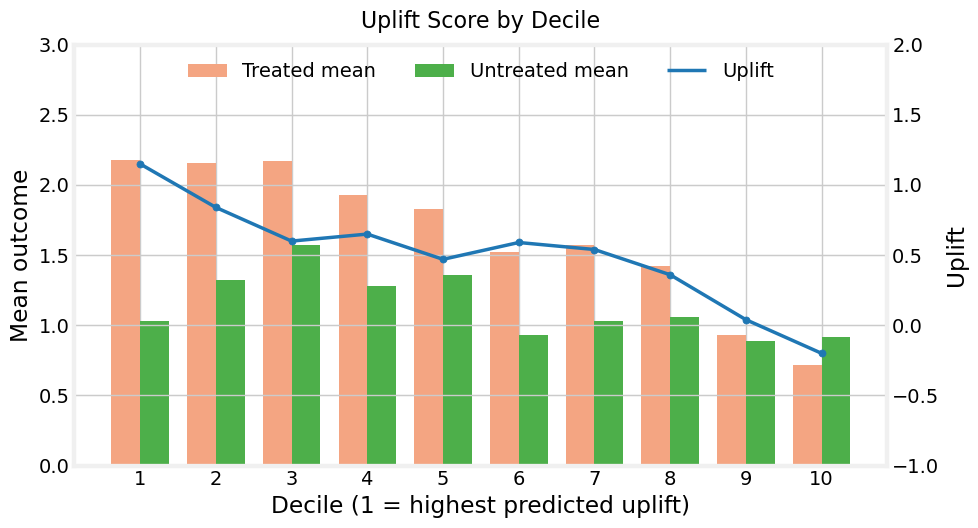

In [163]:
plot_deciles(
    df=summary_m2,
    decile_col="decile",
    treated_col="treated_Y",
    untreated_col="untreated_Y",
    title="Uplift Score by Decile"
)

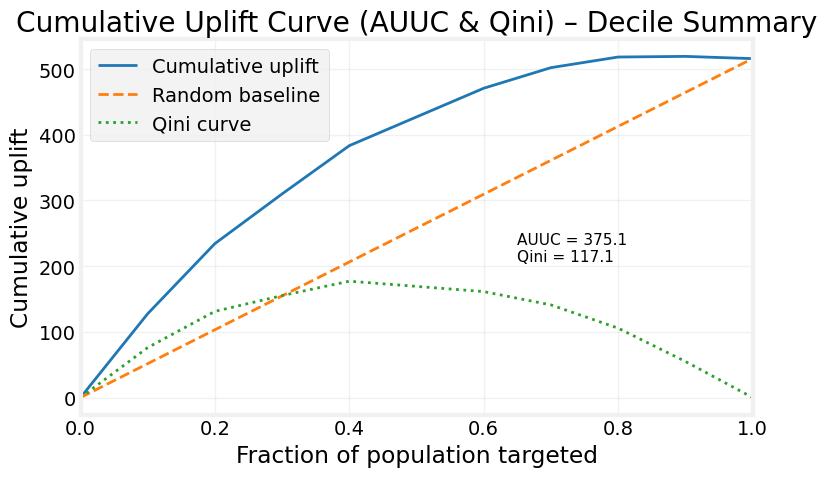

375.06149999999997 117.14649999999999


In [164]:
metrics = auuc_qini(
    decile_df=summary_m2,
    coverage_col="cum_coverage",
    cum_uplift_col="cum_incre_ttl",
    title="Cumulative Uplift Curve (AUUC & Qini) – Decile Summary"
)

print(metrics["AUUC"], metrics["Qini"])

## Modeling Method 3: with the S-Learner in EconML Directly

In [181]:
from econml.metalearners import SLearner
from sklearn.ensemble import GradientBoostingRegressor

# Instantiate the base model (don't pass the class itself)
overall_model =GradientBoostingRegressor(random_state=42) 

# Build and fit the S-Learner
s_learner = SLearner(overall_model=overall_model)
s_learner.fit(Y=df_train[outcome_col], T=df_train[treat_col], X=df_train[feature_cols])

# Predict individual uplift (CATE) on the test set
uplift_hat_m3 = s_learner.effect(df_test[feature_cols])
print(uplift_hat_m3[:5])

[0.198821   0.6486618  0.13419934 0.44805556 0.46181735]


In [182]:
summary_m3, test_scored_m3 = deciles(
    df_scored=df_test,
    uplift_hat=uplift_hat_m3)

summary_m3

,decile,n,n_treated,n_untreated,untreated_Y,treated_Y,uplift_pred,uplift,incre_sum,cum_incre_ttl,cum_n,cum_coverage
0,1,150,115,35,1.06,1.85,0.82,0.79,90.85,90.85,150,0.1
1,2,150,127,23,0.99,2.10,0.73,1.11,140.97,231.82,300,0.2
2,3,150,102,48,1.17,2.27,0.68,1.10,112.20,344.02,450,0.3
3,4,150,88,62,1.47,1.94,0.63,0.47,41.36,385.38,600,0.4
4,5,150,90,60,1.21,1.87,0.59,0.66,59.40,444.78,750,0.5
5,6,150,84,66,1.12,2.09,0.55,0.97,81.48,526.26,900,0.6
6,7,150,60,90,0.92,1.63,0.49,0.71,42.60,568.86,1050,0.7
7,8,150,52,98,0.92,1.54,0.43,0.62,32.24,601.10,1200,0.8
8,9,150,42,108,1.01,1.17,0.36,0.16,6.72,607.82,1350,0.9
9,10,150,28,122,0.89,0.96,0.24,0.07,1.96,609.78,1500,1.0


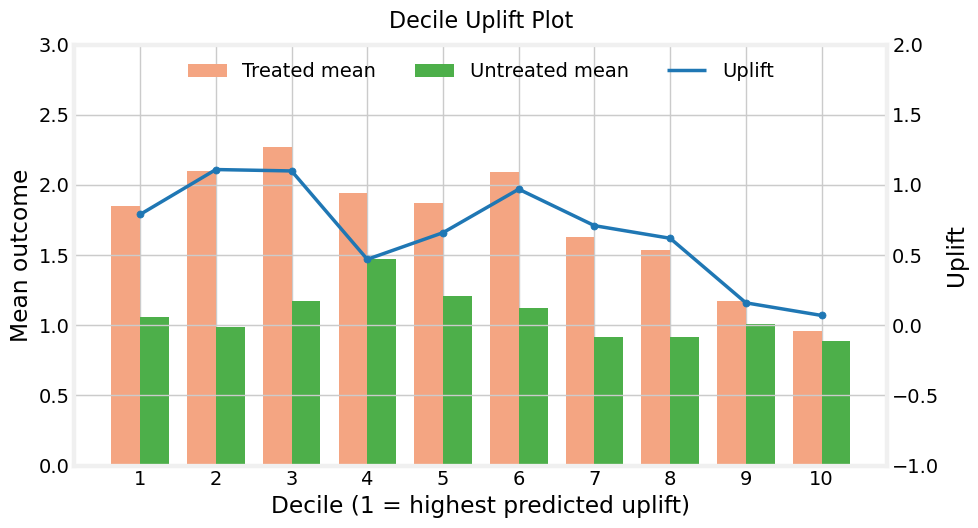

In [183]:
plot_deciles(
    df=summary_m3,
    decile_col="decile",
    treated_col="treated_Y",
    untreated_col="untreated_Y",
    title="Decile Uplift Plot"
)

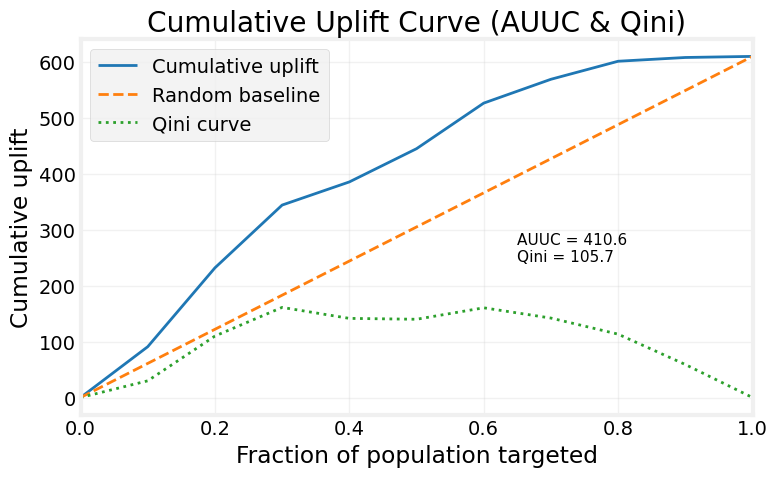

410.578 105.68799999999996


In [184]:
metrics = auuc_qini(
    decile_df=summary_m3,
    coverage_col="cum_coverage",
    cum_uplift_col="cum_incre_ttl",
    title="Cumulative Uplift Curve (AUUC & Qini)"
)

print(metrics["AUUC"], metrics["Qini"])

# Appendix

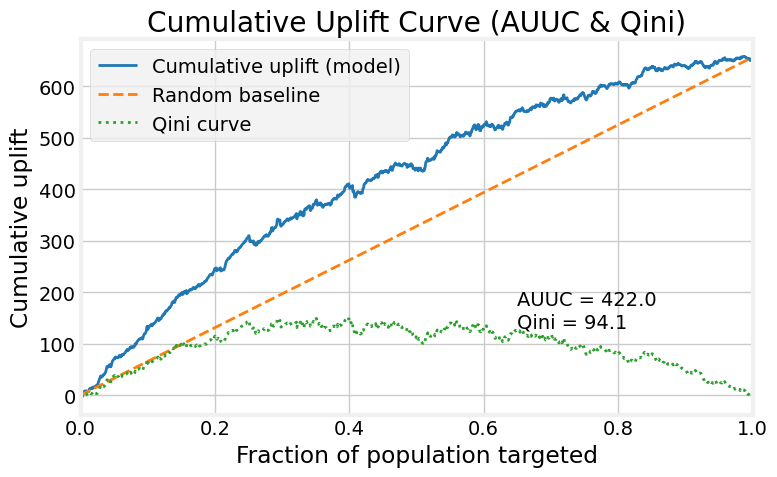

<Figure size 640x480 with 0 Axes>

In [169]:
def auuc_qini(
    data,
    uplift_col: str = "uplift_hat",
    treat_col: str = "T",
    outcome_col: str = "Y",
    title: str = "Cumulative Uplift Curve (AUUC & Qini)"
):

    # Sort by predicted uplift
    d = data.sort_values(uplift_col, ascending=False).reset_index(drop=True)

    # Compute cumulative uplift
    treated_mask = (d[treat_col] == 1)
    y = d[outcome_col].to_numpy()
    treated_y = np.where(treated_mask, y, 0.0)
    control_y = np.where(~treated_mask, y, 0.0)

    cum_treated_y = np.cumsum(treated_y)
    cum_control_y = np.cumsum(control_y)
    cum_treated_n = np.cumsum(treated_mask.astype(int))
    cum_control_n = np.cumsum((~treated_mask).astype(int))

    denom = np.where(cum_control_n == 0, np.nan, cum_control_n)
    cum_uplift = cum_treated_y - cum_control_y * (cum_treated_n / denom)
    cum_uplift = np.nan_to_num(cum_uplift, nan=0.0)

    # Population fraction
    N = len(d)
    frac = np.arange(1, N + 1) / N

    # AUUC & Qini
    auuc = float(np.trapz(cum_uplift, frac))
    total_cum_uplift = float(cum_uplift[-1])
    baseline = frac * total_cum_uplift
    qini = float(np.trapz(cum_uplift - baseline, frac))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
    ax.set_facecolor("white")
    ax.plot(frac, cum_uplift, label="Cumulative uplift (model)", color="#1f77b4", linewidth=2)
    ax.plot(frac, baseline, label="Random baseline", color="#ff7f0e", linestyle="--", linewidth=2)
    ax.plot(frac, cum_uplift - baseline, label="Qini curve", color="#2ca02c", linestyle=":", linewidth=2)

    ax.set_xlabel("Fraction of population targeted")
    ax.set_ylabel("Cumulative uplift")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.legend(loc="best")

    # Annotate AUUC & Qini
    ymin, ymax = float(cum_uplift.min()), float(cum_uplift.max())
    y_annot = ymin + 0.2 * (ymax - ymin) if ymax > ymin else 0.0
    ax.annotate(f"AUUC = {auuc:.1f}\nQini = {qini:.1f}",
                xy=(0.65, y_annot)
               )

    plt.tight_layout()
    plt.show()
    plt.savefig("cumulative_uplift_qini.png", facecolor="white")
    curve_df = pd.DataFrame({"frac": frac, "cum_uplift": cum_uplift, "baseline": baseline})
    
    return {"AUUC": auuc, "Qini": qini, "curve_df": curve_df}

metrics = auuc_qini(test_scored_m1, uplift_col="uplift_hat", treat_col="T", outcome_col="Y")